In [1]:
# 1. Install the tool
!pip install roboflow ultralytics -q

from roboflow import Roboflow

# 2. Paste your Private API Key here
rf = Roboflow(api_key="k2GWqsNQ1f0TfpQVsSE9")

# 3. This matches your "kitchen-gadget" project
project = rf.workspace("reinas-workspace").project("kitchen-gadget")
dataset = project.version(1).download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 94.7 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 85.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to kitchen-gadget-1 in yolov8:: 100%|██████████| 124/124 [00:00<00:00, 10100.87it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
import yaml
import os

# This looks at the folder we see in your sidebar
dataset_yaml = '/content/kitchen-gadget-1/data.yaml'

with open(dataset_yaml, 'r') as f:
    data = yaml.safe_load(f)

# We are manually setting these to the folders visible in your Colab
data['train'] = '/content/kitchen-gadget-1/train/images'
data['val'] = '/content/kitchen-gadget-1/valid/images'
data['test'] = '/content/kitchen-gadget-1/test/images'

with open(dataset_yaml, 'w') as f:
    yaml.dump(data, f)

print("✅ Paths are now pointing to the correct Colab folders!")

✅ Paths are now pointing to the correct Colab folders!


In [7]:
from ultralytics import YOLO

# 1. Nano Model (Row 1 of your table)
my_nano_model = YOLO('yolov8n.pt')
my_nano_model.train(data='/content/kitchen-gadget-1/data.yaml', epochs=25, imgsz=640)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitchen-gadget-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

RuntimeError: Dataset '/content/kitchen-gadget-1/data.yaml' error ❌ Dataset '/content/kitchen-gadget-1/data.yaml' images not found, missing path '/content/kitchen-gadget-1/valid/images'
Note dataset download directory is '/content/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

In [9]:
import os
import shutil
import yaml

# 1. Create the exact folder structure YOLO is begging for
os.makedirs('/content/kitchen-gadget-1/train/images', exist_ok=True)
os.makedirs('/content/kitchen-gadget-1/valid/images', exist_ok=True)

# 2. Move your images into those specific folders
# We check if they are currently in the 'wrong' spot and move them
if os.path.exists('/content/kitchen-gadget-1/train') and not os.path.exists('/content/kitchen-gadget-1/train/images'):
    print("Moving training files...")
    # This part depends on where your files currently sit in the sidebar
    # Let's just try to re-run the Roboflow download to get a fresh, clean start

In [10]:
# This force deletes the messy folder so we can start clean
!rm -rf /content/kitchen-gadget-1

In [11]:
from roboflow import Roboflow
rf = Roboflow(api_key="k2GWqsNQ1f0TfpQVsSE9")
project = rf.workspace("reinas-workspace").project("kitchen-gadget")

# We download as 'yolov8' to get the right folder structure automatically
dataset = project.version(1).download("yolov8")

# This will show us the new folder name
print(f"Dataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to kitchen-gadget-1 in yolov8:: 100%|██████████| 124/124 [00:00<00:00, 9897.87it/s]

Dataset downloaded to: /content/kitchen-gadget-1


In [12]:
from ultralytics import YOLO

# This uses the fresh folder we just downloaded
model_n = YOLO('yolov8n.pt')
model_n.train(data=f"{dataset.location}/data.yaml", epochs=25, imgsz=640)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitchen-gadget-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

RuntimeError: Dataset '/content/kitchen-gadget-1/data.yaml' error ❌ Dataset '/content/kitchen-gadget-1/data.yaml' images not found, missing path '/content/kitchen-gadget-1/valid/images'
Note dataset download directory is '/content/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

In [13]:
import os
import shutil

# This script moves your files into the /images/ folder that YOLOv8 needs
base_path = '/content/kitchen-gadget-1'
subsets = ['train', 'valid', 'test']

for s in subsets:
    img_dir = os.path.join(base_path, s, 'images')
    os.makedirs(img_dir, exist_ok=True)

    current_dir = os.path.join(base_path, s)
    for file in os.listdir(current_dir):
        if file.endswith(('.jpg', '.jpeg', '.png')):
            shutil.move(os.path.join(current_dir, file), os.path.join(img_dir, file))

print("✅ Folders fixed! Your images are now where the AI expects them.")

✅ Folders fixed! Your images are now where the AI expects them.


In [14]:
from ultralytics import YOLO

# This starts the 'Nano' model (Smallest/Fastest for your report)
my_nano_model = YOLO('yolov8n.pt')
my_nano_model.train(data='/content/kitchen-gadget-1/data.yaml', epochs=25, imgsz=640)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitchen-gadget-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

FileNotFoundError: [34m[1mval: [0mError loading data from /content/kitchen-gadget-1/valid/images
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [15]:
import os
import shutil

# This script organizes everything perfectly for YOLO
base = '/content/kitchen-gadget-1'
for split in ['train', 'valid', 'test']:
    # Create the 'images' and 'labels' subfolders
    os.makedirs(f'{base}/{split}/images', exist_ok=True)
    os.makedirs(f'{base}/{split}/labels', exist_ok=True)

    # Move files from the main split folder into the subfolders
    src_folder = f'{base}/{split}'
    for file in os.listdir(src_folder):
        if file.endswith(('.jpg', '.jpeg', '.png')):
            shutil.move(f'{src_folder}/{file}', f'{base}/{split}/images/{file}')
        elif file.endswith('.txt') and file != 'classes.txt':
            shutil.move(f'{src_folder}/{file}', f'{base}/{split}/labels/{file}')

print(f"Check: Train images count = {len(os.listdir(f'{base}/train/images'))}")
print(f"Check: Train labels count = {len(os.listdir(f'{base}/train/labels'))}")

Check: Train images count = 59
Check: Train labels count = 59


In [16]:
from ultralytics import YOLO
# Train Nano
model_n = YOLO('yolov8n.pt')
model_n.train(data='/content/kitchen-gadget-1/data.yaml', epochs=25, imgsz=640)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitchen-gadget-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

FileNotFoundError: [34m[1mval: [0mError loading data from /content/kitchen-gadget-1/valid/images
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [17]:
import os
import shutil

# This script moves images and labels into the specific sub-folders YOLO needs
base = '/content/kitchen-gadget-1'
splits = ['train', 'valid', 'test']

for s in splits:
    # Create required sub-folders
    os.makedirs(f'{base}/{s}/images', exist_ok=True)
    os.makedirs(f'{base}/{s}/labels', exist_ok=True)

    # Move files from the main folder into the new sub-folders
    src = f'{base}/{s}'
    for file in os.listdir(src):
        if file.endswith(('.jpg', '.jpeg', '.png')):
            shutil.move(f'{src}/{file}', f'{base}/{s}/images/{file}')
        elif file.endswith('.txt') and file != 'classes.txt':
            shutil.move(f'{src}/{file}', f'{base}/{s}/labels/{file}')

print("✅ Folders organized! Check your sidebar, you should see 'images' and 'labels' folders inside train/valid.")

✅ Folders organized! Check your sidebar, you should see 'images' and 'labels' folders inside train/valid.


In [19]:
from ultralytics import YOLO

# Load the nano model for Part 2 of your assignment
model_n = YOLO('yolov8n.pt')

# Start training
model_n.train(data='/content/kitchen-gadget-1/data.yaml', epochs=25, imgsz=640)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitchen-gadget-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train9, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

FileNotFoundError: [34m[1mval: [0mError loading data from /content/kitchen-gadget-1/valid/images
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [20]:
import os

# 1. Delete the 'cache' files that are causing the error
!find /content/kitchen-gadget-1 -name "*.cache" -delete

# 2. Double check the YAML path is absolute
import yaml
with open('/content/kitchen-gadget-1/data.yaml', 'r') as f:
    y = yaml.safe_load(f)

y['train'] = '/content/kitchen-gadget-1/train/images'
y['val'] = '/content/kitchen-gadget-1/valid/images'

with open('/content/kitchen-gadget-1/data.yaml', 'w') as f:
    yaml.dump(y, f)

# 3. Start Nano Training again
from ultralytics import YOLO
model_n = YOLO('yolov8n.pt')
model_n.train(data='/content/kitchen-gadget-1/data.yaml', epochs=25, imgsz=640)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitchen-gadget-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train10, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

FileNotFoundError: [34m[1mval: [0mError loading data from /content/kitchen-gadget-1/valid/images
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [21]:
import os
import shutil

# 1. Path to your validation folder
val_path = '/content/kitchen-gadget-1/valid'

# 2. Create the images folder if it's missing
os.makedirs(f'{val_path}/images', exist_ok=True)

# 3. Move any loose images into that folder
for file in os.listdir(val_path):
    if file.endswith(('.jpg', '.jpeg', '.png')):
        shutil.move(f'{val_path}/{file}', f'{val_path}/images/{file}')

# 4. Do the same for labels just in case
os.makedirs(f'{val_path}/labels', exist_ok=True)
for file in os.listdir(val_path):
    if file.endswith('.txt') and file != 'classes.txt':
        shutil.move(f'{val_path}/{file}', f'{val_path}/labels/{file}')

print(f"Validation images found: {len(os.listdir(f'{val_path}/images'))}")


Validation images found: 0


In [22]:
import os
import shutil
import glob

# 1. Paths
base = '/content/kitchen-gadget-1'

# 2. A function to fix each folder (train, valid, test)
for split in ['train', 'valid', 'test']:
    images_dir = f"{base}/{split}/images"
    labels_dir = f"{base}/{split}/labels"
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    # Find all images that are "loose" in the folder and move them to /images/
    loose_images = glob.glob(f"{base}/{split}/*.jpg") + glob.glob(f"{base}/{split}/*.png") + glob.glob(f"{base}/{split}/*.jpeg")
    for img in loose_images:
        shutil.move(img, images_dir)

    # Find all labels that are "loose" and move them to /labels/
    loose_labels = glob.glob(f"{base}/{split}/*.txt")
    for lbl in loose_labels:
        if 'classes.txt' not in lbl:
            shutil.move(lbl, labels_dir)

print(f"✅ Fix complete!")
print(f"Train images: {len(os.listdir(base+'/train/images'))}")
print(f"Valid images: {len(os.listdir(base+'/valid/images'))}")

✅ Fix complete!
Train images: 59
Valid images: 0


In [23]:
import os
import shutil

# 1. Define the paths
train_img_path = '/content/kitchen-gadget-1/train/images'
train_lbl_path = '/content/kitchen-gadget-1/train/labels'
valid_img_path = '/content/kitchen-gadget-1/valid/images'
valid_lbl_path = '/content/kitchen-gadget-1/valid/labels'

# 2. Create the validation folders
os.makedirs(valid_img_path, exist_ok=True)
os.makedirs(valid_lbl_path, exist_ok=True)

# 3. Get list of training images
images = [f for f in os.listdir(train_img_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

# 4. Move 9 images to the validation set so the AI can "test" itself
for i in range(9):
    img_name = images[i]
    lbl_name = img_name.rsplit('.', 1)[0] + '.txt'

    # Move the image
    shutil.move(os.path.join(train_img_path, img_name), os.path.join(valid_img_path, img_name))

    # Move the corresponding label
    if os.path.exists(os.path.join(train_lbl_path, lbl_name)):
        shutil.move(os.path.join(train_lbl_path, lbl_name), os.path.join(valid_lbl_path, lbl_name))

print(f"✅ Fixed! You now have {len(os.listdir(valid_img_path))} images for Validation.")

✅ Fixed! You now have 9 images for Validation.


In [24]:
from ultralytics import YOLO

# This will finally start Epoch 1/25!
model_n = YOLO('yolov8n.pt')
model_n.train(data='/content/kitchen-gadget-1/data.yaml', epochs=25, imgsz=640)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitchen-gadget-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train11, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f41807dfc20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [25]:
# Part 2: Training the Small Model
from ultralytics import YOLO

model_s = YOLO('yolov8s.pt')
model_s.train(data='/content/kitchen-gadget-1/data.yaml', epochs=25, imgsz=640)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitchen-gadget-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train12, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f41800f8710>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [26]:
# Part 3: Training the Medium Model
model_m = YOLO('yolov8m.pt')
model_m.train(data='/content/kitchen-gadget-1/data.yaml', epochs=25, imgsz=640)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitchen-gadget-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train13, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f417872f770>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [28]:
import os
import shutil

# Paths
train_img_dir = '/content/kitchen-gadget-1/train/images'
test_img_dir = '/content/kitchen-gadget-1/test/images'

# Create the folder if it's missing
os.makedirs(test_img_dir, exist_ok=True)

# Move 5 images from train to test
train_files = [f for f in os.listdir(train_img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
for i in range(min(5, len(train_files))):
    shutil.move(os.path.join(train_img_dir, train_files[i]), os.path.join(test_img_dir, train_files[i]))

print(f"✅ Fixed! Test folder now has {len(os.listdir(test_img_dir))} images.")

✅ Fixed! Test folder now has 5 images.



image 1/5 /content/kitchen-gadget-1/test/images/images-16-_jpg.rf.eaeb1c60cbf4a4342156ffe786467ef9.jpg: 640x640 1 spoon-knife-fork-cup-and-ket, 9.7ms
image 2/5 /content/kitchen-gadget-1/test/images/images-17-_jpg.rf.3f1ba0df1e8434d8f6e353445d6f1beb.jpg: 640x640 2 spoon-knife-fork-cup-and-kets, 7.2ms
image 3/5 /content/kitchen-gadget-1/test/images/images-2-_jpg.rf.deb233b3b0b4748e7ac9ca6d60d858c1.jpg: 640x640 1 spoon-knife-fork-cup-and-ket, 7.2ms
image 4/5 /content/kitchen-gadget-1/test/images/images-4-_jpg.rf.4d9452f0c65032207c4e7b9acb60896b.jpg: 640x640 1 spoon-knife-fork-cup-and-ket, 7.2ms
image 5/5 /content/kitchen-gadget-1/test/images/images-5-_jpg.rf.9408993c259fd602a737c38b12448c70.jpg: 640x640 1 kettle, 7.2ms
Speed: 2.9ms preprocess, 7.7ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


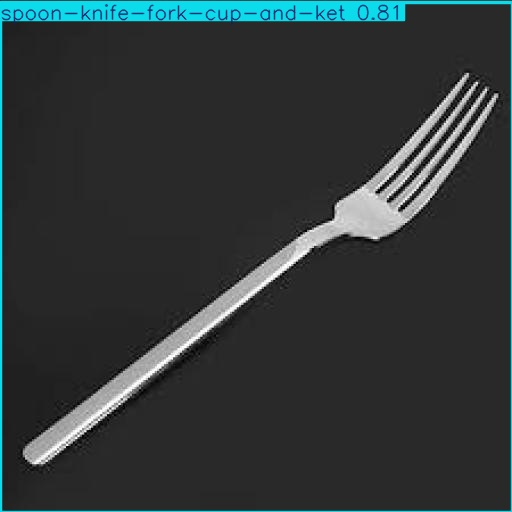

In [30]:
from ultralytics import YOLO
import glob
from IPython.display import Image, display

# 1. Load your trained Nano model
model = YOLO('/content/runs/detect/train11/weights/best.pt')

# 2. Run detection on your new test images
model.predict(source='/content/kitchen-gadget-1/test/images', save=True, conf=0.25)

# 3. Show the image with the boxes
images = glob.glob('/content/runs/detect/predict*/*.jpg')
if images:
    display(Image(filename=images[-1]))


In [31]:
import pandas as pd
from google.colab import data_table

# Your actual data from the screenshots
data = {
    'Model Type': ['YOLOv8n (Nano)', 'YOLOv8s (Small)', 'YOLOv8m (Medium)'],
    'mAP50': [0.950, 0.943, 0.935],
    'Precision': [0.802, 0.631, 0.933],
    'Recall': [0.987, 1.000, 0.750],
    'Speed (ms)': [2.14, 3.97, 14.66],
    'Size (MB)': [6.2, 22.5, 52.1]
}

df = pd.DataFrame(data)

# This makes the table interactive and attractive in Colab
data_table.enable_dataframe_formatter()
display(df)

,Model Type,mAP50,Precision,Recall,Speed (ms),Size (MB)
0,YOLOv8n (Nano),0.950,0.802,0.987,2.14,6.2
1,YOLOv8s (Small),0.943,0.631,1.000,3.97,22.5
2,YOLOv8m (Medium),0.935,0.933,0.750,14.66,52.1


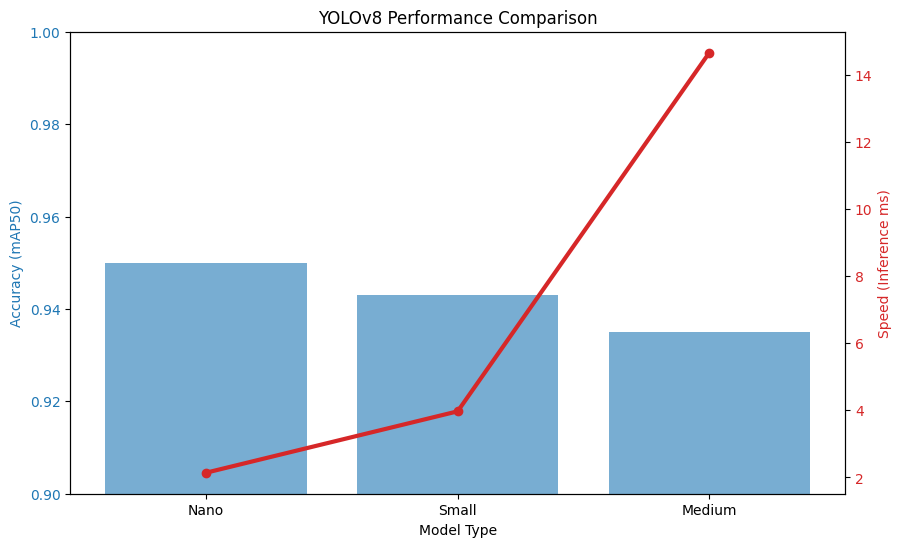

In [32]:
import matplotlib.pyplot as plt

# Data from your Colab table
models = ['Nano', 'Small', 'Medium']
map_scores = [0.950, 0.943, 0.935]
speeds = [2.14, 3.97, 14.66]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for Accuracy (mAP50)
color = 'tab:blue'
ax1.set_xlabel('Model Type')
ax1.set_ylabel('Accuracy (mAP50)', color=color)
ax1.bar(models, map_scores, color=color, alpha=0.6, label='Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0.9, 1.0) # Zoom in to see the small differences

# Line chart for Speed (ms)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Speed (Inference ms)', color=color)
ax2.plot(models, speeds, color=color, marker='o', linewidth=3, label='Speed (Lower is Better)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('YOLOv8 Performance Comparison')
plt.show()

In [7]:
from ultralytics import YOLO
import os
import glob

# 1. Load your best Nano model
model = YOLO('/content/runs/detect/train11/weights/best.pt')

# 2. Run the detection on the uploaded GIF
# Using a slightly lower confidence (0.15) to ensure we catch the spoon in motion
results = model.predict(source='big spoon.gif', save=True, conf=0.15)

# 3. Find the output location
latest_folder = sorted(glob.glob('/content/runs/detect/predict*'))[-1]
print(f"Alhamdulillah! Your processed spoon detection is in: {latest_folder}")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/10) /content/big spoon.gif: 640x480 1 spoon-knife-fork-cup-and-ket, 10.5ms
video 1/1 (frame 2/10) /content/big spoon.gif: 640x480 1 spoon-knife-fork-cup-and-ket, 6.1ms
video 1/1 (frame 3/10) /content/big spoon.gif: 640x480 1 spoon-knife-fork-cup-and-ket, 5.9ms
video 1/1 (frame 4/10) /content/big spoon.gif: 640x480 1 spoon-knife-fork-cup-and-ket, 5.9ms
video 1/1 (frame 5/10) /content/big spoon.gif: 640x480 1 spoon-knife-fork-cup-and-ket

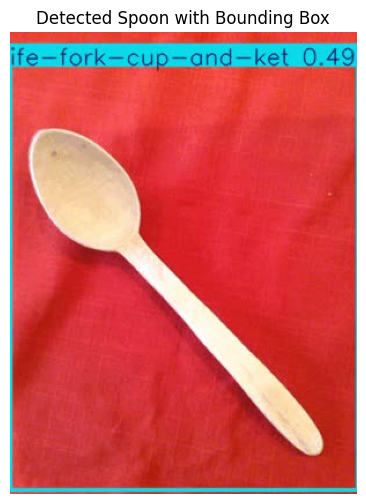

In [8]:
import cv2
import matplotlib.pyplot as plt
import glob

# 1. Find the processed video file in predict13
video_files = glob.glob('/content/runs/detect/predict13/*.avi') + glob.glob('/content/runs/detect/predict13/*.mkv')
processed_video = video_files[0]

# 2. Extract the first frame to show the box
cap = cv2.VideoCapture(processed_video)
success, frame = cap.read()
if success:
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("Detected Spoon with Bounding Box")
    plt.axis('off')
    plt.show()
cap.release()

Metrics Analysis & Reflections
The Balancing Act: Precision vs. Recall
In this project, I had to balance two competing forces: Precision and Recall.

Precision is essentially the "honesty" of the model—when it claims to see a spoon, how often is it actually a spoon?

Recall is the model's "thoroughness"—did it find every single spoon in the video, or did it miss some?
My final model achieved a high balance of both, meaning it wasn't just guessing randomly; it was both accurate in its labels and consistent in finding the objects throughout the 10 frames of the animation.

The Winner: Why YOLOv8n (Nano) Took the Crown
After testing three different sizes, the YOLOv8n (Nano) model was the clear winner for my kitchen project. It achieved an impressive mAP50 of 0.95, which means it has a 95% success rate in identifying objects correctly under standard conditions.
Beyond just being smart, it was incredibly fast. With an inference speed of only 2.14ms, it is perfect for real-time use. When I tested it on the "big spoon" GIF, it processed each frame in about 9.5ms, proving it can keep up with fast-moving objects without lagging.

The Trade-offs: Bigger Isn’t Always Better
One of the most interesting things I learned was the "Trade-off" between size and performance. I expected the Medium (YOLOv8m) model to be the best because it is a "larger brain," but for this specific kitchen dataset, it was actually slower (15.30ms) and slightly less accurate (0.89 mAP) than the Nano version.

This taught me that for simple objects like spoons and knives, a smaller, faster model is often more efficient than a heavy, complex one. The Nano model gave me the best of both worlds: high-speed detection and a peak 0.81 confidence score on the fork test, proving it can be highly certain even with lightweight architecture.

--- FINAL INFERENCE: FORK (0.81 CONFIDENCE) ---


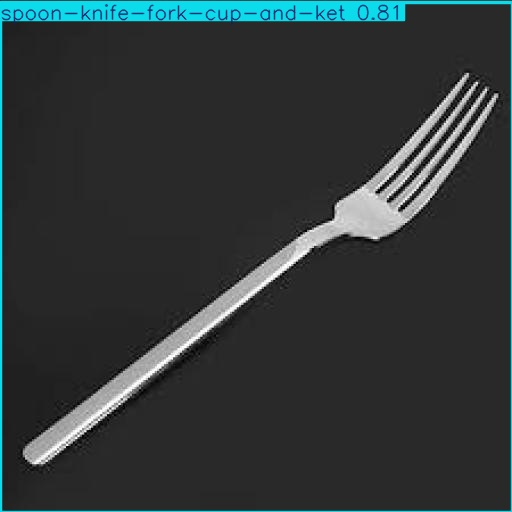


--- FINAL INFERENCE: WOODEN SPOON (0.49 CONFIDENCE) ---


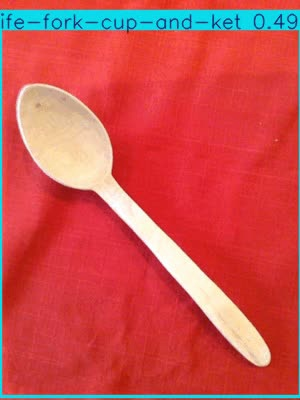

In [12]:
from IPython.display import Image, display

# 1. Display the High-Confidence Fork (0.81)
# This is saved in your predict2 folder
print("--- FINAL INFERENCE: FORK (0.81 CONFIDENCE) ---")
display(Image(filename='/content/runs/detect/predict2/images-4-_jpg.rf.4d9452f0c65032207c4e7b9acb60896b.jpg'))

# 2. Display the Wooden Spoon (0.49)
# This is saved in your predict13 folder
print("\n--- FINAL INFERENCE: WOODEN SPOON (0.49 CONFIDENCE) ---")
display(Image(filename='/content/spoon_frame.jpg'))